# ERR/LFR 實驗結果分析

唯讀分析筆記本：只讀取 `results/` 底下的 csv 與 recall txt 檔案，不重新訓練模型、
不呼叫 `subprocess`、不匯入 `server.py`／`client.py`。若某份檔案不存在，對應的儲存格
會印出提示訊息，不會丟出例外。

In [1]:
%matplotlib inline
import re

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# matplotlib 內建字型（DejaVu Sans）不含中文字符，圖上的中文標題／圖例會變成缺字
# 方框。改用系統內建的微軟正黑體，並關閉 unicode_minus（該字型的「−」全形負號跟
# matplotlib 預設的減號渲染方式衝突，僅次於中文問題但一起關掉比較省事）。
plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

# 本筆記本預期以 model_training/ 為執行目錄開啟（Jupyter 預設 cwd 是筆記本檔案所在
# 目錄）。results/ 在 model_training/ 的上一層，不是底下——run_*.py 寫檔案時用的是
# os.path.join(os.path.dirname(BASE_DIR), "results")，這裡沿用同一個相對關係。
RESULTS_DIR = (Path.cwd() / ".." / "results").resolve()


def load_csv(filename):
    """讀 RESULTS_DIR 底下一份 csv，檔案不存在就印提示並回傳 None，不丟例外。"""
    path = RESULTS_DIR / filename
    if not path.exists():
        print(f"[缺檔] {path} 不存在，略過。")
        return None
    return pd.read_csv(path)


_RECALL_LINE = re.compile(r"^(.+?)\s{2,}(\d+)\s+([\d.]+)\s+(\S+)\s*$")


def load_recall_txt(filename):
    """
    解析 run_err_lfr_experiment.py／run_attack_experiment.py 寫出的逐攻擊類型
    recall/FPR 報告（純文字表格，非 csv）。檔案結構固定：開頭是 model= 路徑與
    幾行 # 註解，接一行 "test_natural overall: ..." 摘要，空行後才是表格本體，
    每一列是 "攻擊類型（可能含空白）  樣本數  數值  metric名稱"，欄位間至少兩個
    空白字元隔開，攻擊類型內部只用單一空白（例如 "nmap SYN flood"），所以用
    "至少兩個空白"當欄位分隔，避免把攻擊類型名稱切壞。
    檔案不存在或表格列一列都解析不出來時回傳 None，不丟例外。
    """
    path = RESULTS_DIR / filename
    if not path.exists():
        print(f"[缺檔] {path} 不存在，略過。")
        return None
    rows = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.rstrip("\n")
            if not line or line.startswith("#") or line.startswith("model="):
                continue
            m = _RECALL_LINE.match(line)
            if not m:
                continue
            attack_type, n, value, metric = m.groups()
            if metric not in ("recall", "FPR"):
                continue
            rows.append({
                "attack_type": attack_type.strip(),
                "n": int(n),
                "value": float(value),
                "metric": metric,
            })
    if not rows:
        print(f"[缺資料] {path} 存在但解析不出任何一列，略過。")
        return None
    return pd.DataFrame(rows)


def parse_excluded(cell):
    """
    把 err_lfr_exclusions.csv 的 excluded_client_ids 欄位轉成 int list。
    這個欄位有三種寫法：空值代表沒有排除（"[]"）、單一 client 是裸數字（"4"）、
    多個 client 是逗號分隔的字串（csv 裡因為含逗號會被引號包起來，例如 "2, 1"）——
    pandas 讀進來後這三種都是字串，統一去掉方括號再用逗號切開。
    """
    s = str(cell).strip()
    if s in ("", "[]", "nan"):
        return []
    s = s.strip("[]")
    return [int(x.strip()) for x in s.split(",") if x.strip()]

**圖1要看什麼**：四種設定（有無攻擊 × 有無 ERR/LFR）的 F1 隨輪次收斂是否一致，尤其是「有攻擊」時 ERR/LFR 有沒有把 F1 拉回接近「無攻擊」的水準。

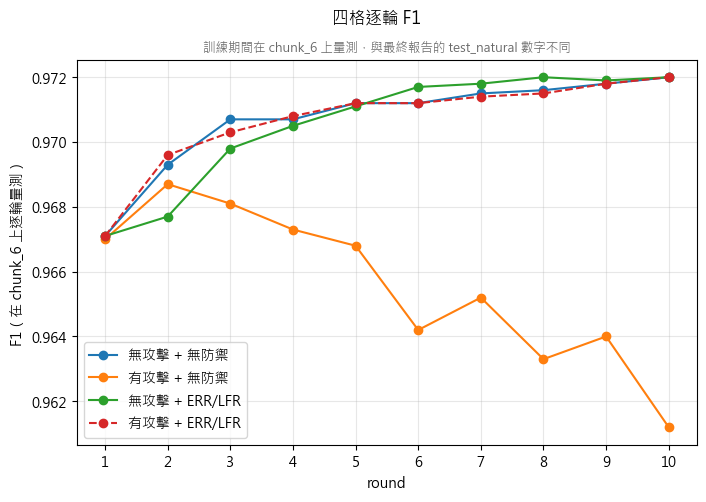

In [2]:
df = load_csv("err_lfr_summary.csv")

if df is not None:
    cell_order = [
        "no_attack_no_defense",
        "attack_no_defense",
        "no_attack_err_lfr",
        "attack_err_lfr",
    ]
    cell_labels = {
        "no_attack_no_defense": "無攻擊 + 無防禦",
        "attack_no_defense": "有攻擊 + 無防禦",
        "no_attack_err_lfr": "無攻擊 + ERR/LFR",
        "attack_err_lfr": "有攻擊 + ERR/LFR",
    }

    fig, ax = plt.subplots(figsize=(8, 5))
    for cell_name in cell_order:
        sub = df[df["config"] == cell_name].sort_values("round")
        if sub.empty:
            print(f"[缺資料] err_lfr_summary.csv 裡沒有 config={cell_name}，略過這條線。")
            continue
        # "有攻擊 + ERR/LFR" 收斂後的數值跟 "無攻擊 + 無防禦" 幾乎重疊，實線會疊在一起
        # 看不出來是兩條線，改虛線讓兩條線在視覺上分得開。
        linestyle = "--" if cell_name == "attack_err_lfr" else "-"
        ax.plot(sub["round"], sub["f1"], marker="o", linestyle=linestyle, label=cell_labels[cell_name])

    ax.set_xlabel("round")
    ax.set_ylabel("F1（在 chunk_6 上逐輪量測）")
    fig.suptitle("四格逐輪 F1", y=0.98)
    ax.set_title("訓練期間在 chunk_6 上量測，與最終報告的 test_natural 數字不同", fontsize=9, color="dimgray")
    ax.set_xticks(range(1, 11))
    ax.legend()
    ax.grid(alpha=0.3)
    plt.show()

**圖2要看什麼**：候選模型 A（該輪全部節點合併、尚未排除任何節點前的模型）的 accuracy 曲線，在 flip_rate=1.0 與 flip_rate=0.3 兩種攻擊強度下走勢是否一致，用來判斷偵測效果會不會隨攻擊強度變弱。

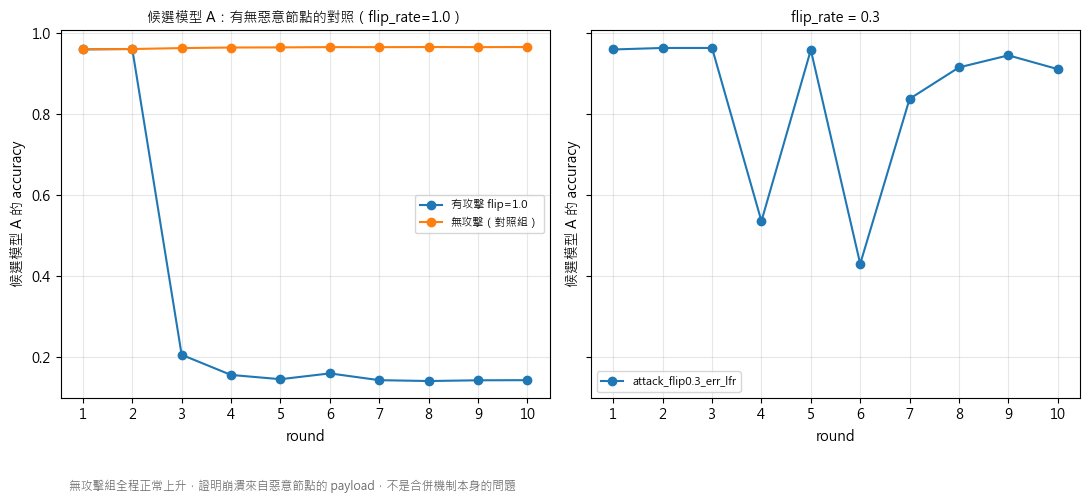

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

candidate_sources = [
    ("候選模型 A：有無惡意節點的對照（flip_rate=1.0）", "err_lfr_candidate_a.csv", axes[0]),
    ("flip_rate = 0.3", "err_lfr_flip03_candidate_a.csv", axes[1]),
]
# err_lfr_candidate_a.csv 同時有 no_attack_err_lfr（沒有惡意節點的對照組）與
# attack_err_lfr（有惡意節點）兩組，用這份對照表把原始 config 名稱換成看得懂的標籤。
config_labels = {
    "no_attack_err_lfr": "無攻擊（對照組）",
    "attack_err_lfr": "有攻擊 flip=1.0",
}

for label, filename, ax in candidate_sources:
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("round")
    ax.set_ylabel("候選模型 A 的 accuracy")
    df = load_csv(filename)
    if df is None:
        ax.text(
            0.5, 0.5, f"{filename}\n不存在",
            ha="center", va="center", transform=ax.transAxes, fontsize=9,
        )
        continue
    # 同一份 csv 可能混著不只一組 config（例如 err_lfr_candidate_a.csv 同時有
    # no_attack_err_lfr 與 attack_err_lfr 兩組），要先照 config 分組再畫，
    # 否則不同組的資料點會被連成同一條不合理的折線。
    for config_name, sub in df.groupby("config"):
        sub = sub.sort_values("round")
        ax.plot(sub["round"], sub["accuracy"], marker="o", label=config_labels.get(config_name, config_name))
    ax.set_xticks(range(1, 11))
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout(rect=[0, 0.07, 1, 1])
fig.text(
    0.27, 0.01,
    "無攻擊組全程正常上升，證明崩潰來自惡意節點的 payload，不是合併機制本身的問題",
    ha="center", fontsize=8.5, color="dimgray",
)
plt.show()

**圖3要看什麼**：每個節點逐輪的 err_impact／lfr_impact 數值，確認惡意節點（紅色）是否穩定高於誠實節點（藍色）——這兩個數值就是 ERR/LFR 判斷「該不該排除這個節點」的依據本身。

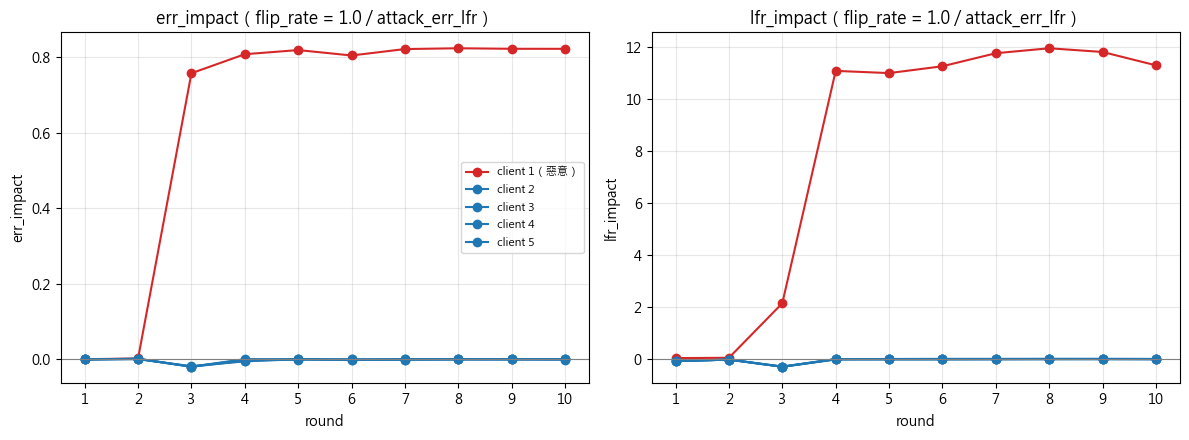

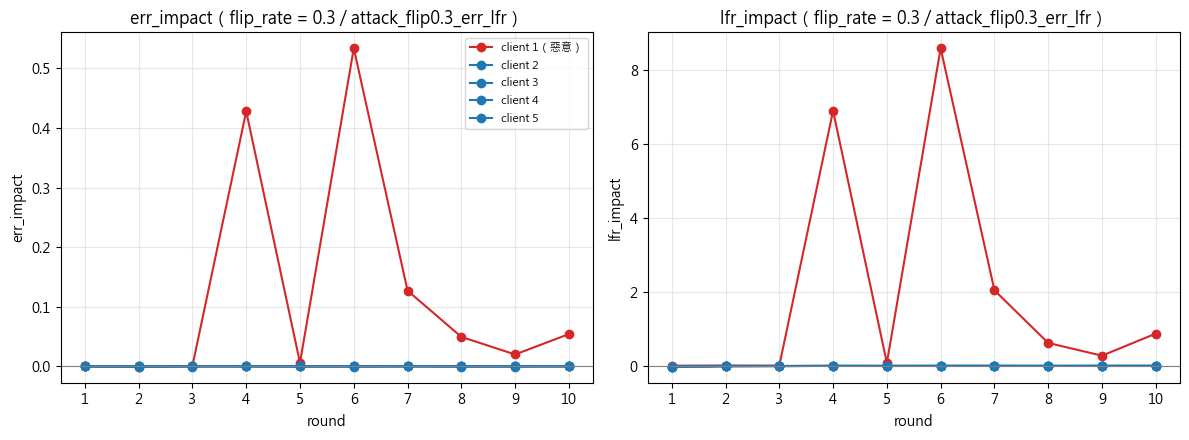

In [4]:
impact_sources = [
    # err_lfr_client_impact.csv 同時有 no_attack_err_lfr（沒有惡意節點）與
    # attack_err_lfr（有惡意節點）兩組；圖3的目的是標示惡意節點的訊號，
    # no_attack_err_lfr 沒有惡意節點可標示，畫出來只會是 5 條全藍的線、
    # 容易被誤認成「flip=1.0 沒有分色」，所以這裡只取跟講稿引用範圍一致的
    # attack_err_lfr。config_filter=None 表示不過濾、把檔案裡的組都畫出來。
    ("flip_rate = 1.0", "err_lfr_client_impact.csv", "attack_err_lfr"),
    ("flip_rate = 0.3", "err_lfr_flip03_client_impact.csv", None),
]

for label, filename, config_filter in impact_sources:
    df = load_csv(filename)
    if df is None:
        continue
    if config_filter is not None:
        df = df[df["config"] == config_filter]
        if df.empty:
            print(f"[缺資料] {filename} 裡沒有 config={config_filter}，略過。")
            continue

    for config_name, config_df in df.groupby("config"):
        fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
        for ax, metric in zip(axes, ["err_impact", "lfr_impact"]):
            for client_id, sub in config_df.groupby("client_id"):
                sub = sub.sort_values("round")
                malicious = bool(sub["malicious"].iloc[0])
                color = "tab:red" if malicious else "tab:blue"
                client_label = f"client {client_id}" + ("（惡意）" if malicious else "")
                ax.plot(sub["round"], sub[metric], marker="o", color=color, label=client_label)
            ax.axhline(0, color="grey", linewidth=0.8)
            ax.set_xlabel("round")
            ax.set_ylabel(metric)
            ax.set_title(f"{metric}（{label} / {config_name}）")
            ax.set_xticks(range(1, 11))
            ax.grid(alpha=0.3)

        handles, labels = axes[0].get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        axes[0].legend(by_label.values(), by_label.keys(), fontsize=8)
        plt.tight_layout()
        plt.show()

**圖4要看什麼**：三種情境（無攻擊基準／有攻擊無防禦／有攻擊有防禦）在哪些攻擊類型上的 recall 分開最明顯，用來確認 ERR/LFR 拉回的具體是哪些攻擊類型，而不是全面拉高；「集中式對照」是把 5 個節點資料集中訓練的模型，recall 在 `ros2 reconnaissance`／`ros2 reflection` 這兩種聯邦架構測不到的類型上明顯比前三組高，但**不能只看這張圖就認為集中式比較好**——它在 `observe` 上的 FPR 是 0.3753，比前三組（0.01～0.02）高一個數量級，test_natural 整體 F1 只有 0.8898（前三組都在 0.96 以上），代價非常大，細節見 `eval_centralized_on_test_rare.py` 執行時印出的四組並排表格。

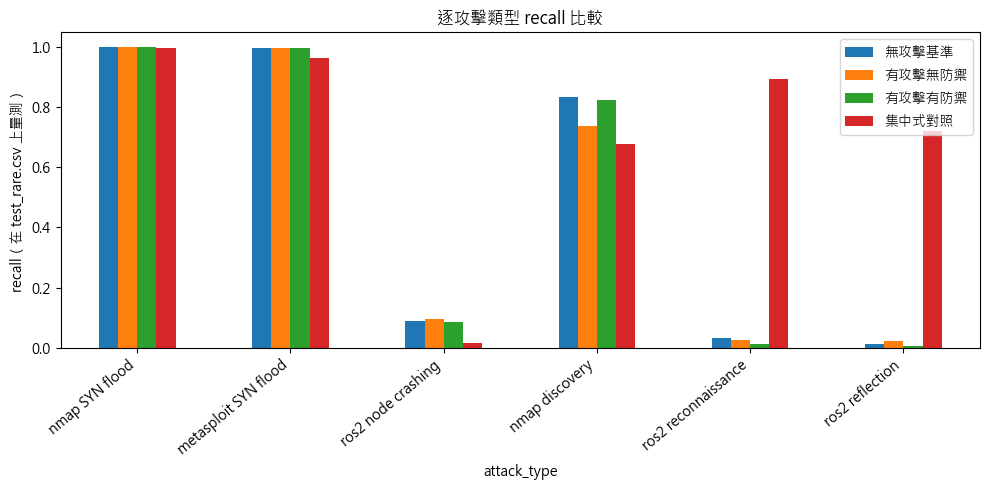

In [5]:
recall_sources = [
    ("無攻擊基準", "err_lfr_final_recall_no_attack_no_defense.txt"),
    ("有攻擊無防禦", "err_lfr_final_recall_attack_no_defense.txt"),
    ("有攻擊有防禦", "err_lfr_final_recall_attack_err_lfr.txt"),
    ("集中式對照", "centralized_test_rare_recall.txt"),
]

recall_series = {}
for label, filename in recall_sources:
    df = load_recall_txt(filename)
    if df is None:
        continue
    recall_only = df[df["metric"] == "recall"]
    recall_series[label] = recall_only.set_index("attack_type")["value"]

if not recall_series:
    print("[缺資料] recall txt 都不存在或都解析失敗，無法畫圖。")
else:
    combined = pd.DataFrame(recall_series)
    ax = combined.plot(kind="bar", figsize=(10, 5))
    ax.set_ylabel("recall（在 test_rare.csv 上量測）")
    ax.set_title("逐攻擊類型 recall 比較")
    ax.legend(title="")
    plt.xticks(rotation=40, ha="right")
    plt.tight_layout()
    plt.show()

**圖5要看什麼**：每一輪實際排除了哪個 client_id，確認惡意節點是否被穩定鎖定、以及無攻擊情境下的誤刪是不是隨機分散在不同誠實節點上，而不是集中誤殺同一個。

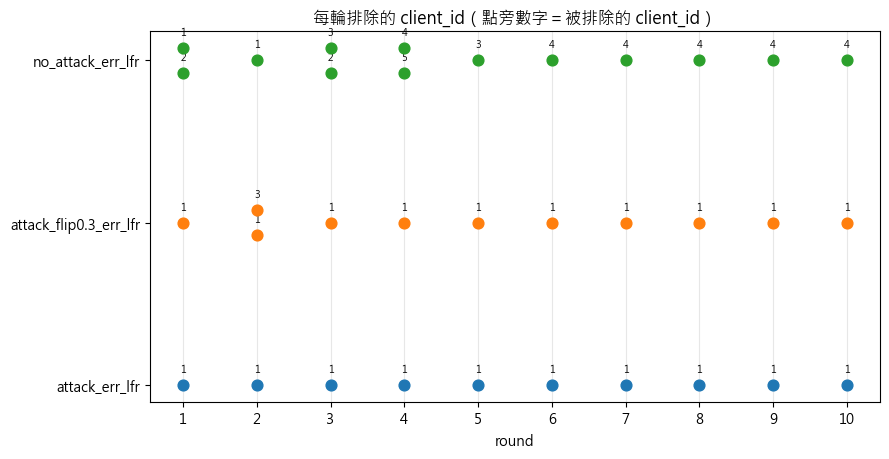

In [6]:
def load_exclusions(filename, configs):
    df = load_csv(filename)
    if df is None:
        return None
    df = df[df["config"].isin(configs)].copy()
    df["excluded"] = df["excluded_client_ids"].apply(parse_excluded)
    return df


exclusion_frames = [
    load_exclusions("err_lfr_exclusions.csv", ["no_attack_err_lfr", "attack_err_lfr"]),
    load_exclusions("err_lfr_flip03_exclusions.csv", ["attack_flip0.3_err_lfr"]),
]
exclusion_frames = [df for df in exclusion_frames if df is not None]

if not exclusion_frames:
    print("[缺資料] err_lfr_exclusions.csv 與 err_lfr_flip03_exclusions.csv 都不存在，無法畫圖。")
else:
    all_excl = pd.concat(exclusion_frames, ignore_index=True)
    configs_present = sorted(all_excl["config"].unique())
    colors = plt.cm.tab10.colors

    fig, ax = plt.subplots(figsize=(9, 0.9 * len(configs_present) + 2))
    for row_idx, cfg in enumerate(configs_present):
        sub = all_excl[all_excl["config"] == cfg]
        color = colors[row_idx % len(colors)]
        for _, row in sub.iterrows():
            excluded = row["excluded"]
            n = len(excluded)
            for j, client_id in enumerate(excluded):
                # 同一輪排除多個節點時，把點沿 y 方向錯開，避免疊在同一個位置看不出來有幾個。
                y = row_idx + (j - (n - 1) / 2) * 0.15
                ax.scatter(row["round"], y, color=color, s=60, zorder=3)
                ax.text(row["round"], y + 0.08, str(client_id), ha="center", fontsize=7)

    ax.set_yticks(range(len(configs_present)))
    ax.set_yticklabels(configs_present)
    ax.set_xlabel("round")
    ax.set_xticks(range(1, 11))
    ax.set_title("每輪排除的 client_id（點旁數字＝被排除的 client_id）")
    ax.grid(alpha=0.3, axis="x")
    plt.tight_layout()
    plt.show()